In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [7]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print(os.listdir("/content"))

['.config', 'netflix_titles.csv', 'archive.zip', 'sample_data']


In [8]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [9]:
import pandas as pd

df = pd.read_csv("/content/netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of Dataset:
(8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Missing Values:
show_i

In [11]:
df = df.drop_duplicates()

df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['date_added'] = df['date_added'].fillna("Unknown")

df.dropna(subset=['duration'], inplace=True)

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [12]:
print(df.describe(include='all'))

       show_id   type   title director     cast        country  \
count     8804   8804    8804     8804     8804           8804   
unique    8804      2    8804     4528     7692            749   
top      s8807  Movie  Zubaan  Unknown  Unknown  United States   
freq         1   6128       1     2634      825           2815   
mean       NaN    NaN     NaN      NaN      NaN            NaN   
std        NaN    NaN     NaN      NaN      NaN            NaN   
min        NaN    NaN     NaN      NaN      NaN            NaN   
25%        NaN    NaN     NaN      NaN      NaN            NaN   
50%        NaN    NaN     NaN      NaN      NaN            NaN   
75%        NaN    NaN     NaN      NaN      NaN            NaN   
max        NaN    NaN     NaN      NaN      NaN            NaN   

             date_added  release_year rating  duration  \
count              8804   8804.000000   8804      8804   
unique             1767           NaN     14       220   
top     January 1, 2020          

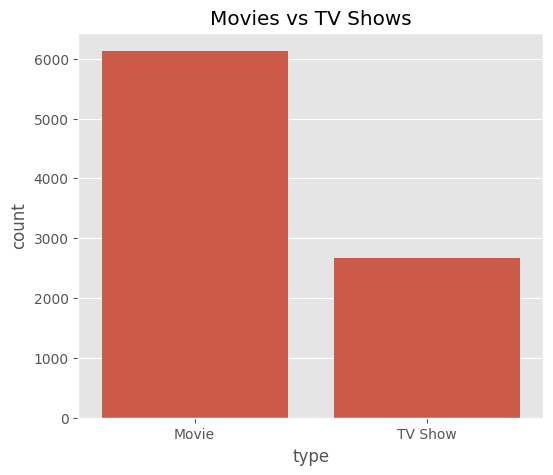

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")

plt.show()

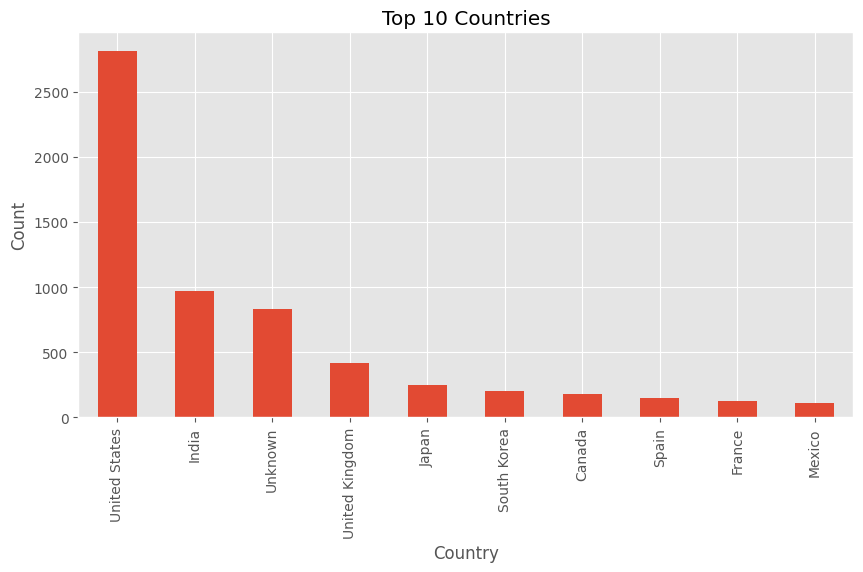

In [14]:
country=df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

country.plot(kind='bar')

plt.title("Top 10 Countries")

plt.xlabel("Country")

plt.ylabel("Count")

plt.show()

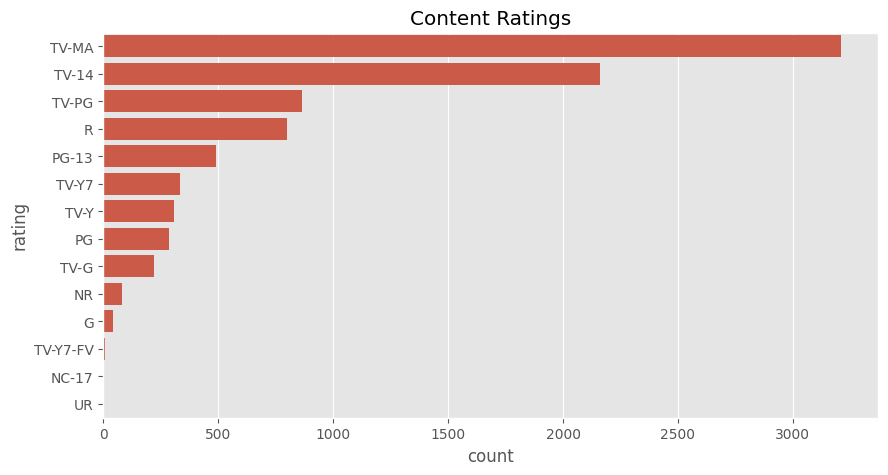

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index)

plt.title("Content Ratings")

plt.show()

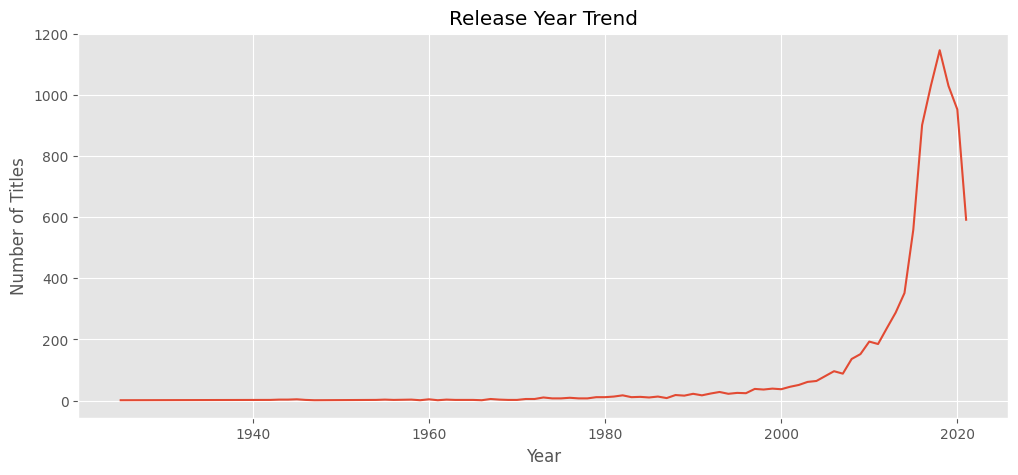

In [16]:
year=df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

year.plot()

plt.title("Release Year Trend")

plt.xlabel("Year")

plt.ylabel("Number of Titles")

plt.show()

/tmp/ipykernel_2582/3433018573.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_num']=movies['duration'].str.replace(" min","").astype(int)


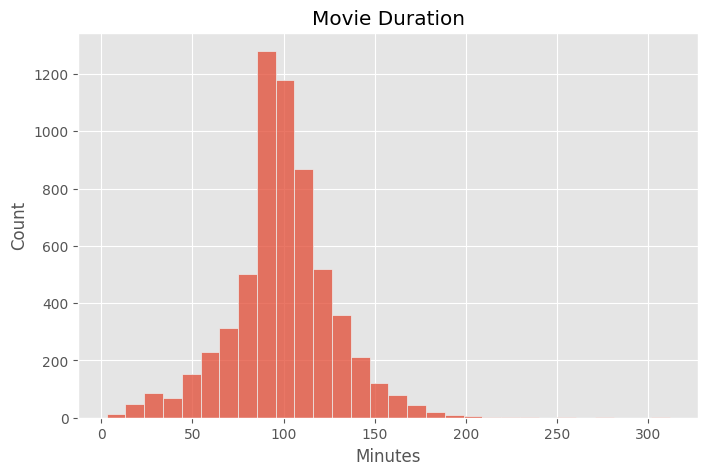

In [17]:
movies=df[df['type']=="Movie"]

movies['duration_num']=movies['duration'].str.replace(" min","").astype(int)

plt.figure(figsize=(8,5))

sns.histplot(movies['duration_num'],bins=30)

plt.title("Movie Duration")

plt.xlabel("Minutes")

plt.show()

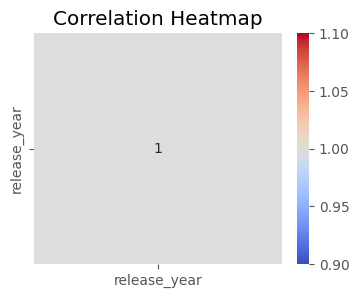

In [18]:
numeric=df[['release_year']]

plt.figure(figsize=(4,3))

sns.heatmap(numeric.corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [19]:
print("Question 1")
print(df['type'].value_counts())

print("\nQuestion 2")
print(df['country'].value_counts().head(10))

print("\nQuestion 3")
print(df['rating'].value_counts())

print("\nQuestion 4")
print(df.groupby('type')['release_year'].max())

print("\nQuestion 5")
print(df['release_year'].describe())

Question 1
type
Movie      6128
TV Show    2676
Name: count, dtype: int64

Question 2
country
United States     2815
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

Question 3
rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

Question 4
type
Movie      2021
TV Show    2021
Name: release_year, dtype: int64

Question 5
count    8804.000000
mean     2014.180259
std         8.820647
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


In [20]:
print("INSIGHTS REPORT")

print("1. Netflix contains more Movies than TV Shows.")

print("2. The United States contributes the highest number of titles.")

print("3. TV-MA is the most common content rating.")

print("4. Content production has increased rapidly after 2015.")

print("5. Most movies have a duration between 80 and 120 minutes.")

INSIGHTS REPORT
1. Netflix contains more Movies than TV Shows.
2. The United States contributes the highest number of titles.
3. TV-MA is the most common content rating.
4. Content production has increased rapidly after 2015.
5. Most movies have a duration between 80 and 120 minutes.


In [21]:
print("The surprising finding is that Netflix has far more Movies than TV Shows, and content production increased significantly after 2015.")

The surprising finding is that Netflix has far more Movies than TV Shows, and content production increased significantly after 2015.


In [22]:
df.to_csv("cleaned_netflix.csv",index=False)

print("Dataset saved successfully.")

Dataset saved successfully.
